In [1]:
import pandas as pd

train_data = pd.read_csv("../data/train.csv")
test_data = pd.read_csv("../data/test.csv")

In [2]:
data_dictionary = {
    "row_id": "identifier",
    "credit_limit": "predictor",
    "sex": "predictor / audit attribute",
    "education": "predictor",
    "marital_status": "predictor",
    "age": "predictor",
    "latest_repayment_status": "predictor",
    "maximum_repayment_delay_6m": "predictor",
    "delayed_months_6m": "predictor",
    "average_bill_6m": "predictor",
    "bill_change_sep_to_apr": "predictor",
    "total_payment_6m": "predictor",
    "payment_to_bill_ratio_6m": "predictor",
    "zero_payment_months_6m": "predictor",
    "utilization_sep": "predictor",
    "repayment_assistance_plan": "predictor",
    "payment_difficulty_next_month": "target",
    "predicted_class": "submission"
}

categorical_columns = [
    "sex",
    "education",
    "marital_status",
    "repayment_assistance_plan",
]

In [3]:
from sklearn.model_selection import train_test_split

predictor_columns = [
    column for column, role in data_dictionary.items() if "predictor" in role
]
target_column = [
    column for column, role in data_dictionary.items() if role == "target"
][0]

# Split only the labeled data. Keep the unlabeled test data untouched for final predictions.
X = train_data[predictor_columns]
y = train_data[target_column]

X_train, X_validation, y_train, y_validation = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=411,
    stratify=y,
)

X_test = test_data[predictor_columns]

In [4]:
# Transform categorical variables into one-hot encoded features

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat = encoder.fit_transform(X_train[categorical_columns])
X_validation_cat = encoder.transform(X_validation[categorical_columns])
X_test_cat = encoder.transform(X_test[categorical_columns])

numerical_columns = [
    col for col in predictor_columns
    if col not in categorical_columns
]

X_train_num = X_train[numerical_columns]
X_validation_num = X_validation[numerical_columns]
X_test_num = X_test[numerical_columns]

In [5]:
# Combine the one-hot encoded categorical features and the numerical features into a single feature matrix

encoded_categorical_columns = encoder.get_feature_names_out(categorical_columns)

X_train_cat = pd.DataFrame(
    X_train_cat,
    columns=encoded_categorical_columns,
    index=X_train.index
)

X_validation_cat = pd.DataFrame(
    X_validation_cat,
    columns=encoded_categorical_columns,
    index=X_validation.index
)

X_test_cat = pd.DataFrame(
    X_test_cat,
    columns=encoded_categorical_columns,
    index=X_test.index
)

X_train_encoded = pd.concat(
    [X_train_num, X_train_cat],
    axis=1
)

X_validation_encoded = pd.concat(
    [X_validation_num, X_validation_cat],
    axis=1
)

X_test_encoded = pd.concat(
    [X_test_num, X_test_cat],
    axis=1
)

X_train_encoded.head()

,credit_limit,age,latest_repayment_status,maximum_repayment_delay_6m,delayed_months_6m,average_bill_6m,bill_change_sep_to_apr,total_payment_6m,payment_to_bill_ratio_6m,zero_payment_months_6m,...,education_graduate_school,education_high_school,education_other,education_university,education_unknown,marital_status_married,marital_status_other_or_unknown,marital_status_single,repayment_assistance_plan_no,repayment_assistance_plan_yes
21143,60000,34,2,2,1,59000,-800,13500,0.04,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
9555,80000,65,0,0,0,51600,77100,9600,0.03,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
16143,160000,26,-1,0,0,11300,-8100,72400,1.07,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
22939,20000,23,0,2,1,16400,-500,8000,0.08,1,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
11685,340000,62,0,0,0,495100,37800,116400,0.04,0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [ ]:
from interpret.glassbox import ClassificationTree
from sklearn.metrics import accuracy_score, balanced_accuracy_score, recall_score
from sklearn.model_selection import StratifiedKFold

# Estimate performance across five stratified folds of the labeled training partition.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=411)
cv_scores = {
    "accuracy": [],
    "balanced_accuracy": [],
    "recall_class_0": [],
    "recall_class_1": [],
}

for train_indices, validation_indices in cv.split(X_train_encoded, y_train):
    fold_tree = ClassificationTree()
    fold_tree.fit(
        X_train_encoded.iloc[train_indices],
        y_train.iloc[train_indices],
    )
    fold_predictions = fold_tree.predict(
        X_train_encoded.iloc[validation_indices]
    )
    fold_targets = y_train.iloc[validation_indices]
    cv_scores["accuracy"].append(
        accuracy_score(fold_targets, fold_predictions)
    )
    cv_scores["balanced_accuracy"].append(
        balanced_accuracy_score(fold_targets, fold_predictions)
    )
    cv_scores["recall_class_0"].append(
        recall_score(fold_targets, fold_predictions, pos_label=0)
    )
    cv_scores["recall_class_1"].append(
        recall_score(fold_targets, fold_predictions, pos_label=1)
    )

for metric_name, scores in cv_scores.items():
    print(f"Five-fold {metric_name}: {sum(scores) / len(scores):.3f} +/- {pd.Series(scores).std(ddof=0):.3f}")

In [6]:
from interpret import show
from interpret.data import ClassHistogram

hist = ClassHistogram().explain_data(X_train, y_train, name='Train Data')
show(hist)

<!-- http://127.0.0.1:7001/1449872848752/ -->

In [7]:
from interpret.glassbox import ClassificationTree
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report

tree = ClassificationTree()
tree.fit(X_train_encoded, y_train)

validation_predictions = tree.predict(X_validation_encoded)
print(f"Validation accuracy: {accuracy_score(y_validation, validation_predictions):.3f}")
print(
    f"Validation balanced accuracy: "
    f"{balanced_accuracy_score(y_validation, validation_predictions):.3f}"
)
print(classification_report(y_validation, validation_predictions))

Validation accuracy: 0.805
Validation balanced accuracy: 0.560
              precision    recall  f1-score   support

           0       0.81      0.98      0.89      5909
           1       0.70      0.14      0.23      1591

    accuracy                           0.80      7500
   macro avg       0.76      0.56      0.56      7500
weighted avg       0.79      0.80      0.75      7500



In [8]:
from interpret import show
tree_global = tree.explain_global(name='Tree')
show(tree_global)

<!-- http://127.0.0.1:7001/1449923572608/ -->

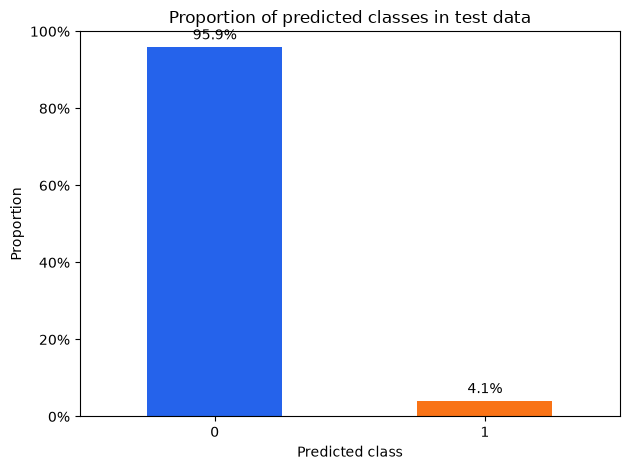

,row_id,credit_limit,sex,education,marital_status,age,latest_repayment_status,maximum_repayment_delay_6m,delayed_months_6m,average_bill_6m,bill_change_sep_to_apr,total_payment_6m,payment_to_bill_ratio_6m,zero_payment_months_6m,utilization_sep,repayment_assistance_plan,predicted_class
0,CR26-128173,50000,male,graduate_school,single,25,0,0,0,27700,31600,21700,0.13,0,0.80,no,0
1,CR26-102911,280000,female,university,married,41,1,1,1,100,300,600,0.63,4,0.00,no,0
2,CR26-104960,420000,male,university,married,38,0,0,0,262500,108200,56200,0.04,0,0.70,no,0
3,CR26-123913,270000,male,university,single,44,0,0,0,247400,48900,56400,0.04,0,1.02,no,0
4,CR26-111750,120000,female,graduate_school,single,29,-1,0,0,1700,-2100,12000,1.20,0,0.00,yes,0


In [9]:
# Classify the unlabeled test data and create a prediction file

import matplotlib.pyplot as plt

test_predictions = tree.predict(X_test_encoded)

# Keep the original test predictors alongside each prediction for debugging.
submission = test_data.copy()
submission["predicted_class"] = test_predictions
submission.to_csv("../data/test_predictions.csv", index=False)

class_proportions = (
    submission["predicted_class"]
    .value_counts(normalize=True)
    .sort_index()
)

ax = class_proportions.plot(
    kind="bar",
    color=["#2563eb", "#f97316"],
    title="Proportion of predicted classes in test data",
    ylabel="Proportion",
    xlabel="Predicted class",
    ylim=(0, 1),
)
ax.set_xticklabels(class_proportions.index, rotation=0)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

for index, proportion in enumerate(class_proportions):
    ax.text(index, proportion + 0.02, f"{proportion:.1%}", ha="center")

plt.tight_layout()
plt.show()

submission.head()